# 245. How many bits an exact reduced-alphabet seed can carry, and how many a proteome search needs

A remote homolog at 20-30% identity carries too little information, on average, for an
exact k-mer seed in any reduced alphabet to rank it above chance in a search of a whole
proteome. This notebook puts numbers on that for one pair, human BCL2 against
*C. elegans* CED-9, and the 19,732 canonical human proteins that notebook 241 searched.

No search is run here. Every input number was printed by an earlier notebook and is read
back from its saved output by `scripts/make_245_inputs.py`, into `tables/245_inputs.tsv`.
Each row there says whether the number was **measured**, is a **table value** from the
literature, or is **approximate**. Numbers this notebook computes from a model are named
as such where they appear.

| input | from |
|---|---|
| Cohen's κ and longest exact runs on aligned homologs | notebook 230 (main) |
| recall of a 10-residue seed with extension | notebook 232 (main) |
| ranks, E-values and chance scores on the human proteome | notebook 241 (PR #46, #48) |
| combined-alphabet ranks | notebook 242 (PR #48) |
| database sizes n and constants K | kmerseek docs, Part 1 |
| 0.38 bits per position for 20 letters | BLOSUM45 (Henikoff and Henikoff 1992), as kmerseek docs Part 2 uses it |
| BCL2 and CED-9 sequences, USalign pairs | kmerseek `docs/examples/bcl2_vs_ced9_pair_example.html` |

In [1]:
import math
import sys
from pathlib import Path

import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import bits_ceiling_utils as bu

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(90)
v = bu.inputs()
bu.inputs_table()

quantity,value,unit,kind,source
str,f64,str,str,str
"""kappa_hp_thomas_dill2_pfam_20_30""",0.463,"""none""","""measured""","""nb 230 section 2, Pfam seed pairs at 20-30% identity"""
"""kappa_protein20_pfam_20_30""",0.199,"""none""","""measured""","""nb 230 section 2, Pfam seed pairs at 20-30% identity"""
"""kappa_hp_thomas_dill2_scope_20_30""",0.433,"""none""","""measured""","""nb 230 section 7, SCOPe cross-family pairs at 20-30% identity"""
"""longest_run_mean_hp_thomas_dill2_pfam_20_30""",13.0,"""residues""","""measured""","""nb 230 section 4, Pfam pairs at 20-30% identity"""
"""longest_run_null_mean_hp_thomas_dill2_pfam_20_30""",6.3,"""residues""","""measured""","""nb 230 section 4, the same Pfam pairs with the target shuffled"""
"""longest_run_mean_hp_thomas_dill2_scope_20_30""",12.2,"""residues""","""measured""","""nb 230 section 4, SCOPe cross-family pairs at 20-30% identity"""
"""longest_run_null_mean_hp_thomas_dill2_scope_20_30""",6.1,"""residues""","""measured""","""nb 230 section 4, the same SCOPe cross-family pairs with the target shuffled"""
"""recall_seed10_extend_20_30""",0.355,"""fraction of pairs""","""measured""","""nb 232 section 2, hp_thomas_dill2, penalty 2, null FPR 0.001 per comparison"""
"""recall_seed10_extend_30_40""",0.635,"""fraction of pairs""","""measured""","""nb 232 section 2, hp_thomas_dill2, penalty 2, null FPR 0.001 per comparison"""


## 1. The pair: the BH1 block of BCL2 and CED-9

One gapless stretch, BCL2 130-166 against CED-9 154-190, is the running example. It is the
BH1 region, the place the two proteins are known to align. Below: the residues, a match
line, then the same stretch in two hydrophobic/polar (HP) alphabets. A class-identical run
is a stretch of consecutive positions where both proteins have the same class; it is the
longest exact k-mer the two share there.

BCL2             130 FATVVEELFRDGVNWGRIVAFFEFGGVMCVESVNREM 166
                                    ||      |||              5 of 37 identical
CED-9            154 RTVGNAQTDQCPMSYGRLIGLISFGGFVAAKMMESVE 190

hp_lehninger2 classes (h = AFGILMPVWY, p = the rest)
BCL2             130 hhphhpphhpphhphhphhhhhphhhhhphpphppph 166
                        |  |  ||||||||||||||||||| || |||     26 of 37 same class
CED-9            154 pphhphppppphhphhphhhhhphhhhhhhphhpphp 190
                              ^^^^^^^^^^^^^^^^^^^   longest class-identical run: 19, BCL2 139-157, CED-9 163-181

hp_thomas_dill2 classes (h = ACFILMVWY, p = the rest)
BCL2             130 hhphhpphhppphphpphhhhhphpphhhhpphppph 166
                           |  | |||||||| ||||||||||| |||     24 of 37 same class
CED-9            154 pphpphpppphphphpphhphhphpphhhhphhpphp 190
                                         ^^^^^^^^^^^   longest class-identical run: 11, BCL2 150-160, CED-9 174-184

USalign on the AlphaFold models puts 25 of

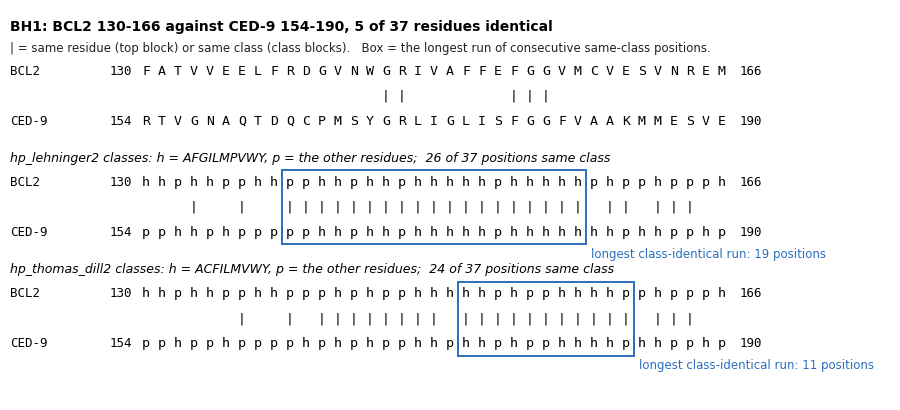

In [2]:
block = bu.bh1_block()
bu.print_bh1(block)
agree, L = bu.usalign_agreement()
print(f"\nUSalign on the AlphaFold models puts {agree} of {L} BH1 positions on this same diagonal "
      f"(BCL2 140-164); it shifts BCL2 130-139 by 4 to 5 residues and 165-166 by 1.")
bu.fig_bh1(block, bu.FIG / "245_bh1_alignment.png")

## 2. Bits per aligned position, $I_A$

Write $I_A$ for the information one aligned position of a true homologous pair carries
about relatedness, in alphabet $A$. It is the mutual information between the query's class
and the target's class at that position, in bits per aligned position:

$$I_A = \sum_{a,\,b} \Pr(a, b)\,\log_2 \frac{\Pr(a, b)}{\Pr(a)\,\Pr(b)} \qquad (1)$$

- $\Pr(a, b)$: the chance that a true pair has class $a$ in the query and $b$ in the target at one aligned position
- $\Pr(a)$, $\Pr(b)$: the class shares of query and target

$I_A$ is also the expected log-likelihood ratio, per position, between "these two
positions descend from one ancestral residue" and "these two positions are unrelated". It
is therefore the most any score can collect on average from one position (Altschul 1991;
the log-odds matrix attains it).

**A reduced alphabet can only lose information.** A reduced alphabet is a fixed map $\phi$
from the 20 amino acids to classes. For any such map,

$$I_A = I\bigl(\phi(X);\,\phi(Y)\bigr) \le I(X;\,Y) = I_{20} \qquad (2)$$

where $X$ and $Y$ are the aligned residues. This is the data-processing inequality
(Cover and Thomas 2006, Theorem 2.8.1). It holds for every alphabet at once, with no model of
evolution. The only number it needs is $I_{20}$.

**$I_{20}$ is not measured here.** 0.38 bits per position is the relative entropy of BLOSUM45
(Henikoff and Henikoff 1992), the 20-letter matrix used for 20-30% identity. It is a table
value. Measuring $I_{20}$ on notebook 230's aligned pairs would make the ceiling a measurement.

**What two letters carry, under a model.** Part 2 of the kmerseek docs models a true pair
with the copy rate $\kappa$ (Cohen's κ): at each position the target copies the query's
class with probability $\kappa$ and otherwise draws its class from the class shares. The
next cell puts in the κ that notebook 230 measured for hp_thomas_dill2 and the class shares
implied by its chance match rate on the human proteome (notebook 241). The result is a
**modelled** $I_{\text{HP}}$, not a measurement.

In [3]:
cs = bu.chance_scores()
pr_unrel = dict(zip(cs["alphabet"], cs["pr_match_unrelated"]))
kappa = v["kappa_hp_thomas_dill2_pfam_20_30"]
shares = bu.two_letter_shares(pr_unrel["hp_thomas_dill2"])
I_hp_model = bu.mutual_information(bu.copy_rate_joint(shares, kappa))
I_20 = v["I_20_blosum45"]
L = block["length"]
bits_block_20 = L * I_20
bits_block_hp = L * I_hp_model
print(f"I_20 (BLOSUM45, table value)                      = {I_20:.2f} bits per position")
print(f"I_HP, copy-rate model, hp_thomas_dill2, κ = {kappa:.3f},")
print(f"  class shares h = {shares[0]:.3f}, p = {shares[1]:.3f} (human proteome)  = {I_hp_model:.3f} bits per position")
print(f"bits_block, 20-letter ceiling:  {L} × {I_20:.2f}  = {bits_block_20:.1f} bits")
print(f"bits_block, two letters (model): {L} × {I_hp_model:.3f} = {bits_block_hp:.1f} bits")

I_20 (BLOSUM45, table value)                      = 0.38 bits per position
I_HP, copy-rate model, hp_thomas_dill2, κ = 0.463,
  class shares h = 0.390, p = 0.610 (human proteome)  = 0.157 bits per position
bits_block, 20-letter ceiling:  37 × 0.38  = 14.1 bits
bits_block, two letters (model): 37 × 0.157 = 5.8 bits


## 3. Bits a hit needs, $\text{bits}_\text{needed}$

There are two thresholds, one for the exact seed and one for the scored region. Notebooks
241 and 242 wrote "about 32 bits for E = 1"; Part 2 of the docs wrote "about 25 on one
proteome". They are the two thresholds below, and they measure different things.

**The scored region.** Karlin and Altschul (1990) give the expected number of chance
regions scoring at least $S$ as $E = K\,m\,n\,e^{-\lambda S}$. Write the score in bits,
$S_\text{bits} = \lambda S / \ln 2$. Then

$$\text{bits}_\text{needed}(E) = \log_2 \frac{K\,m\,n}{E} = \log_2 K + \log_2 m + \log_2 n - \log_2 E \qquad (3)$$

- $K$: the share of the $m \cdot n$ query-by-target position pairs that can start an independent region
- $m$: query length (CED-9, 280 residues)
- $n$: residues in the database

At $E = 1$ a region needs $\log_2(K\,m\,n)$ bits: one more bit for every doubling of the
database or of the query.

**The exact seed.** An exact $k$-residue class match between unrelated sequences happens at
one query-target position pair with probability $\Pr(\text{match} \mid \text{unrelated})^k$,
if positions are independent. There are $m \cdot n$ position pairs, so a seed stands out
(fewer than one expected by chance) only if its rarity reaches

$$\text{bits}_\text{seed needed} = \log_2(m\,n), \qquad \text{rarity of a } k\text{-residue seed} = -k\,\log_2 \Pr(\text{match} \mid \text{unrelated}) \qquad (4)$$

$K$ is not in Equation (4) because every position pair is a place a seed could sit.
Real proteins repeat classes along helices and strands, so an exact run is less rare than
the independent-positions figure says (kmerseek docs Part 1, $r_\text{database}$).

**Which n and K.** The human index's own fitted $K$ is in notebook 241's `arms.csv`, which is not in
the repository. The values below use the docs' "one proteome" row: $n \approx 1.1 \times 10^7$
residues (approximate) and $K = 0.018$ copied from Swiss-Prot (labelled "not calibrated" there).

In [4]:
m = block["ced9_length"]
n = v["n_residues_proteome"]
need_region = bu.bits_needed_region(v["K_proteome"], m, n)
need_seed = bu.bits_needed_seed(m, n)
run = block["hp_lehninger2"]["run_length"]
seed_have = bu.seed_bits(run, pr_unrel["hp_lehninger2"])
chance_seeds = m * n * pr_unrel["hp_lehninger2"] ** run
print(f"region, E = 1:  log2(K·m·n) = log2({v['K_proteome']} × {m} × {n:.1e}) = {need_region:.1f} bits")
print(f"seed:           log2(m·n)   = log2({m} × {n:.1e})           = {need_seed:.1f} bits")
print(f"longest exact hp_lehninger2 run in BH1: {run} residues × -log2({pr_unrel['hp_lehninger2']}) = {seed_have:.1f} bits")
print(f"  so about {chance_seeds:,.0f} exact {run}-residue class matches are expected by chance per search")
print(f"  (a model count of seed placements; notebook 241 measured 3,195 human proteins hit at hp_lehninger2 k=19)")
for p, q in (("BCL2", "Ced9"), ("CD47", "P66")):
    E = v[f"best_evalue_{p}"]
    print(f"measured: {p}'s best E-value when {q} is the query is {E:,.0f}, "
          f"so its best region is log2(E) = {math.log2(E):.1f} bits short of E = 1")

region, E = 1:  log2(K·m·n) = log2(0.018 × 280 × 1.1e+07) = 25.7 bits
seed:           log2(m·n)   = log2(280 × 1.1e+07)           = 31.5 bits
longest exact hp_lehninger2 run in BH1: 19 residues × -log2(0.501) = 18.9 bits
  so about 6,102 exact 19-residue class matches are expected by chance per search
  (a model count of seed placements; notebook 241 measured 3,195 human proteins hit at hp_lehninger2 k=19)
measured: BCL2's best E-value when Ced9 is the query is 1,955, so its best region is log2(E) = 10.9 bits short of E = 1
measured: CD47's best E-value when P66 is the query is 707, so its best region is log2(E) = 9.5 bits short of E = 1


## 4. Bits the pair has against bits the search needs

One bar per quantity. Blue: what the BH1 block has, or can have at most. Red: what the
search needs. Every blue bar is shorter than the red bar in its panel.

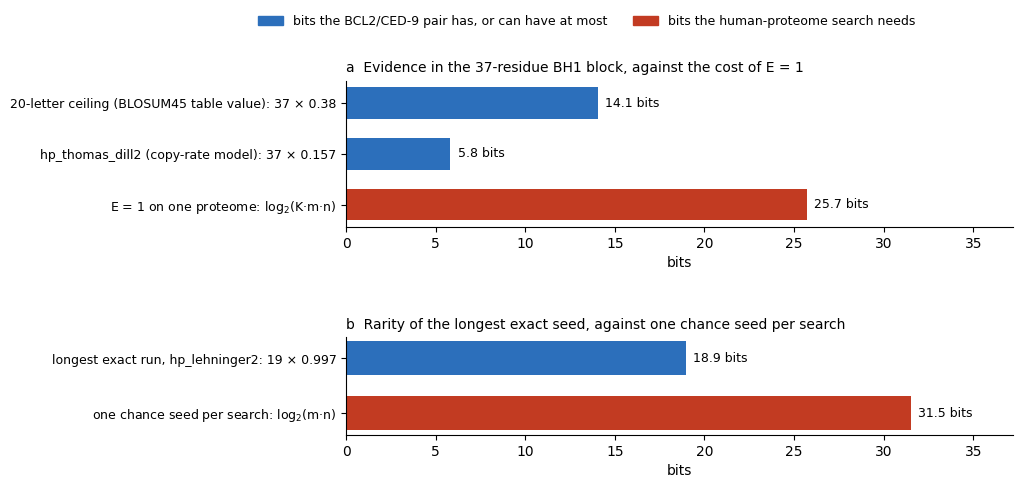

In [5]:
vals = {
    "bits_block_20": bits_block_20, "bits_block_hp": bits_block_hp,
    "bits_needed_region": need_region, "seed_bits_bh1": seed_have, "bits_needed_seed": need_seed,
    "label_ceiling20": f"20-letter ceiling (BLOSUM45 table value): {L} × {I_20:.2f}",
    "label_coin2": f"hp_thomas_dill2 (copy-rate model): {L} × {I_hp_model:.3f}",
    "label_need_region": "E = 1 on one proteome: log$_2$(K·m·n)",
    "label_seed_have": f"longest exact run, hp_lehninger2: {run} × {-math.log2(pr_unrel['hp_lehninger2']):.3f}",
    "label_need_seed": "one chance seed per search: log$_2$(m·n)",
}
bu.fig_bits_have_vs_need(vals, bu.FIG / "245_bits_have_vs_need.png")

## 5. How the cost grows with the database

Equation (3) at each database the kmerseek docs calibrated, and Equation (4) as a line.
Both rise by one bit per doubling of $n$. The BH1 block stays under every one of them, even
at its 20-letter ceiling.

shape: (4, 3)
┌─────────────────────────────┬───────────┬──────┐
│ name                        ┆ n         ┆ bits │
│ ---                         ┆ ---       ┆ ---  │
│ str                         ┆ f64       ┆ f64  │
╞═════════════════════════════╪═══════════╪══════╡
│ SCOPe40                     ┆ 2.6e6     ┆ 24.0 │
│ one proteome (K not fitted) ┆ 1.1e7     ┆ 25.7 │
│ Swiss-Prot                  ┆ 2e8       ┆ 29.9 │
│ UniRef50                    ┆ 1.1000e10 ┆ 35.3 │
└─────────────────────────────┴───────────┴──────┘


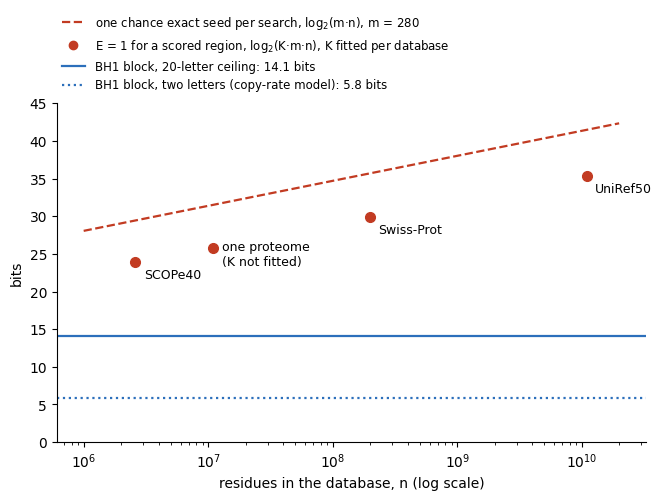

In [6]:
names = {"scope40": "SCOPe40", "proteome": "one proteome\n(K not fitted)", "swissprot": "Swiss-Prot",
         "uniref50": "UniRef50"}
dbs = [{"name": names[k], "n": v[f"n_residues_{k}"],
        "bits": bu.bits_needed_region(v[f"K_{k}"], m, v[f"n_residues_{k}"])} for k in names]
print(pl.DataFrame(dbs).with_columns(pl.col("name").str.replace("\n", " "), pl.col("bits").round(1)))
bu.fig_scaling({"m": m, "bits_block_20": bits_block_20, "bits_block_hp": bits_block_hp}, dbs,
               bu.FIG / "245_bits_needed_vs_database_size.png")

## 6. Conservation and reachability are different quantities

**Conservation** is per position: Cohen's κ, the class match rate above chance as a share
of the room above chance. **Reachability** is whether an exact seed of length $k$ exists at
all: the share of pairs whose longest class-identical run is at least $k$. If positions were
independent, a given window of $k$ positions would be all same-class with probability
$\Pr(\text{same})^k$, which falls exponentially in $k$ while κ does not move. Notebook 230
measured both on the same 37,085 Pfam pairs at 20-30% identity.

k:            5      7     10     15     19     23     26     30
reachable 0.999  0.972  0.776  0.307  0.112  0.038  0.017  0.006
κ, hp_thomas_dill2: 0.463 (Pfam), 0.433 (SCOPe cross-family); protein20: 0.199 (Pfam)
mean longest exact run: 13.0 (Pfam), 12.2 (SCOPe); the same pairs shuffled: 6.3, 6.1


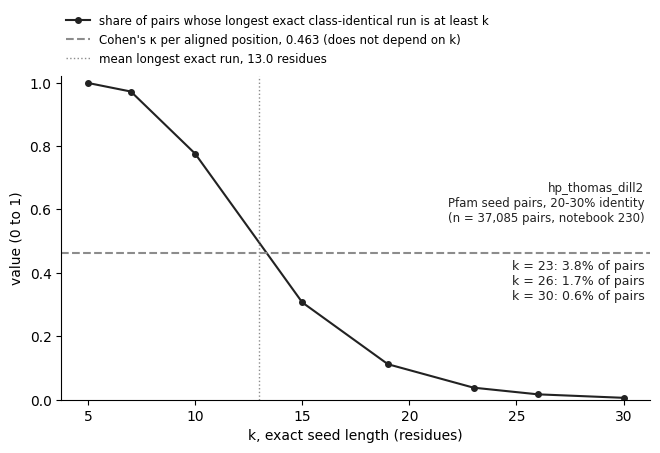

In [7]:
reach = bu.reach_by_k()
r = reach.filter((pl.col("dataset") == "Pfam") & (pl.col("identity_bin") == "20-30%")
                 & (pl.col("alphabet") == "hp_thomas_dill2"))
print("k:        " + "  ".join(f"{k:>5}" for k in r["k"]))
print("reachable " + "  ".join(f"{f:>5.3f}" for f in r["fraction_of_pairs_reachable"]))
print(f"κ, hp_thomas_dill2: {v['kappa_hp_thomas_dill2_pfam_20_30']:.3f} (Pfam), "
      f"{v['kappa_hp_thomas_dill2_scope_20_30']:.3f} (SCOPe cross-family); "
      f"protein20: {v['kappa_protein20_pfam_20_30']:.3f} (Pfam)")
print(f"mean longest exact run: {v['longest_run_mean_hp_thomas_dill2_pfam_20_30']:.1f} (Pfam), "
      f"{v['longest_run_mean_hp_thomas_dill2_scope_20_30']:.1f} (SCOPe); "
      f"the same pairs shuffled: {v['longest_run_null_mean_hp_thomas_dill2_pfam_20_30']:.1f}, "
      f"{v['longest_run_null_mean_hp_thomas_dill2_scope_20_30']:.1f}")
bu.fig_conservation_vs_reach(reach, v, bu.FIG / "245_conservation_vs_reach.png")

## 7. Two alphabets have no E-value at any k, and a third is at the edge

$\lambda$ is the positive root of $\sum_{a,b} \Pr(a)\,\Pr(b)\,e^{\lambda s_{ab}} = 1$, where
$s_{ab}$ is the score for a query class $a$ against a target class $b$. kmerseek scores
$+1$ for a match and $-C$ for a mismatch. A positive root then exists only when one
position between unrelated sequences scores below zero on average:

$$\Pr(\text{match} \mid \text{unrelated}) - C \cdot \bigl(1 - \Pr(\text{match} \mid \text{unrelated})\bigr) < 0 \qquad (5)$$

The values are notebook 241's, with each alphabet's mismatch penalty $C$ taken from its κ.

shape: (5, 4)
┌───────────────────┬────────────────────┬────────────────────┬────────────────────────────────┐
│ alphabet          ┆ pr_match_unrelated ┆ mismatch_penalty_C ┆ expected_score_chance_position │
│ ---               ┆ ---                ┆ ---                ┆ ---                            │
│ str               ┆ f64                ┆ f64                ┆ f64                            │
╞═══════════════════╪════════════════════╪════════════════════╪════════════════════════════════╡
│ gbmr7             ┆ 0.393              ┆ 0.32               ┆ 0.19876                        │
│ hp_lehninger_hpc3 ┆ 0.479              ┆ 0.87               ┆ 0.02573                        │
│ gbmr4             ┆ 0.401              ┆ 0.67               ┆ -0.00033                       │
│ polarity4         ┆ 0.334              ┆ 0.54               ┆ -0.02564                       │
│ sdm12             ┆ 0.141              ┆ 0.24               ┆ -0.06516                       │
└───────────────

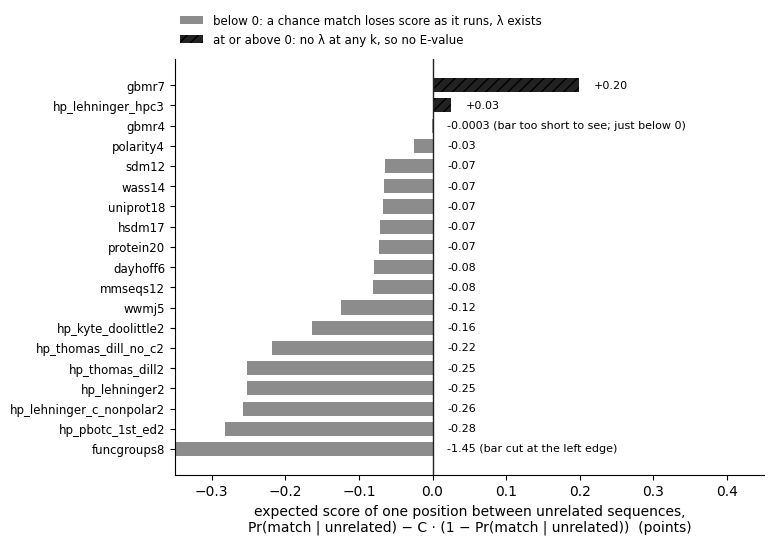

In [8]:
print(cs.sort("expected_score_chance_position", descending=True).head(5))
bu.fig_chance_score(cs, bu.FIG / "245_chance_score_by_alphabet.png")

## 8. What this shows

1. **The ceiling is below the cost.** The 37-residue BH1 block carries at most 14.1 bits
   at the 20-letter ceiling, and about 5.8 bits in two letters under the copy-rate model.
   An E-value of 1 on a proteome the size of the human one costs about 25.7 bits for a
   scored region. The ceiling holds for every reduced alphabet by Equation (2).
2. **The ceiling bounds the average, not one pair.** $I_A$ is an expected log-likelihood
   ratio, so a single pair can carry more than $L \cdot I_A$. BH1 does: its exact
   19-residue hp_lehninger2 run is worth 18.9 bits of rarity. That is still 12.6 bits short of
   the 31.5 an exact seed needs, so about 6,100 chance matches as rare are expected in one search.
3. **The measured E-values agree.** BCL2's best region is 10.9 bits short of E = 1
   and CD47's is 9.5 bits short (notebook 241, measured against the index's own fit).
4. **"32 bits" and "25 bits" are two different thresholds.** $\log_2(m\,n) = 31.5$ is where an
   exact seed stands out. $\log_2(K\,m\,n) = 25.7$ is where a scored region reaches E = 1. The
   prose of notebooks 241 and 242 called the first one the cost of E = 1.
5. **Reach, not conservation, is what an exact seed loses.** κ for hp_thomas_dill2 is 0.463,
   but only 3.8% of the same pairs share an exact 23-mer, 1.7% a 26-mer and 0.6% a 30-mer.
6. **gbmr7 and hp_lehninger_hpc3 cannot give an E-value at any k.** gbmr4 sits at −0.0003,
   just below zero, so its λ exists and is close to 0.